# Introduction

This jupyter notebook shows a demo of discoverying the effective gene pairs that are important to cell-cell colocalization by running the perturbation analysis of SpatialFormer.

In principle, the perturbation analysis includes the following steps:
1. Replace each gene pairs with their counterparts.
2. Inspecting the perturbation results of the genes.
3. Select the top k most effective gene pairs and analyze their effects.


It takes about 3-4 hours to get the gene pairs

## Prerequisite:

To analyze the effects of gene pairs, run the following command:

```python
python perturbation_analysis.py -ct1 T-cells  \
                                -ct2 Macrophages \
                                -pair_num 100 \
                                -num_procs 8\
                                -index /home/sxr280/Spatialformer/data/sample_cell_index.pkl\
                                -sample VUILD96MF\
                                -ckp /home/sxr280/Spatialformer_lumi/output/checkpoints/61slides.ckpt\
                                -cache_dir /home/sxr280/Spatialformer/cache \
                                -dataset /home/sxr280/Spatialformer/cache/xenium_VUILD96MF_pair \
                                -base_dir /home/sxr280/Spatialformer_6_10
```

WARNING: This script can be executed with any combination of cell types, provided they exist in the slide. By default, the "cell_num" parameter is set to 100. Increasing the "cell_num" will significantly slow down the program but may yield more robust and generalizable results. You can also crop the slide to focus only on specific cells of interest by running the following command:


```python
python perturbation_analysis.py -ct1 T-cells  \
                                -ct2 Macrophages \
                                -pair_num 100 \
                                -num_procs 8\
                                -index /home/sxr280/Spatialformer/data/sample_cell_index.pkl\
                                -sample VUILD96MF\
                                -ckp /home/sxr280/Spatialformer_lumi/output/checkpoints/61slides.ckpt\
                                -cache_dir /home/sxr280/Spatialformer/cache \
                                -dataset /home/sxr280/Spatialformer/cache/xenium_VUILD96MF_pair \
                                -base_dir /home/sxr280/Spatialformer_6_10\ 
                                -cci /home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/data/VUILD96MF_croped_cell_id.npy
```
In this command, the [VUILD96MF_croped_cell_id.npy](https://github.com/TerminatorJ/Spatialformer/tree/master/downstream/cell_cell_communication/data) file contains the fibrosis features in the slides, which exclusively include the cells of Macrophages and T-cells.

After running the script, you will find the result file "all_infos_alllung_crop_id.pkl" in the ./data/ directory.  
The following scripts are based on this generated pickled file.

For spp1+ macrophage and t-cell

```python
python perturbation_analysis.py \
    -ct1 T-cells \
    -ct2 "SPP1+ Macrophages" \
    -pair_num 100 \
    -num_procs 8 \
    -index /home/sxr280/Spatialformer/data/sample_cell_index.pkl \
    -sample VUILD96MF \
    -ckp /home/sxr280/Spatialformer_lumi/output/checkpoints/61slides.ckpt \
    -cache_dir /home/sxr280/Spatialformer/cache \
    -dataset /home/sxr280/Spatialformer/cache/xenium_VUILD96MF_pair \
    -base_dir /home/sxr280/Spatialformer_6_10 \
    -cci /home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/data/VUILD96MF_croped_cell_id.npy
```

In [103]:
import pickle
import numpy as np
from tqdm import tqdm
import pandas as pd
from scipy import stats
import sys
sys.path.append("/home/sxr280/Spatialformer_6_10/utils")
from utils import stat_test, ovlp_database, filter_df

Transfer the results to the dataframe.
- Calculate the mean gene expression level
- Use the student T-test to get the p-value of the gene pairs, and set the null hyphothesis as X~N(0,1)

Loading the token vocabulary

In [2]:
import json
with open("/home/sxr280/Spatialformer_6_10/tokenizer/tokenv4.json", "r") as f:
    vocab = json.load(f)
    vocab = {j:i for i,j in vocab.items()}

refine the database

In [3]:
all_infos = pickle.load(open("/home/sxr280/Spatialformer/downstream/cell_cell_communication/data/all_infos_alllung_crop_id_Mac_T.pkl", "rb"))
#Optional 1: use the CellChat database
database_path1 = "/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/data/ligand_receptor_database.csv"
#Optional 2: use the Cellnest database
database_path2 = "/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/data/CellNEST_database.csv"
mac_t_pair_df = stat_test(all_infos, vocab)
mac_t_pair_df = ovlp_database(mac_t_pair_df, database_path1, database_path2)
mac_t_ranked_df = filter_df(mac_t_pair_df)

  7%|▋         | 1963/26806 [00:01<00:12, 2038.46it/s]/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:502: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: invalid value encountered in double_scalars
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
100%|██████████| 26806/26806 [00:12<00:00, 2184.98it/s]
/home/sxr280/Spatialformer_6_10/utils/utils.py:1624: SettingWithCopyWarning: 
A value is trying to be set on a copy

Save the results

In [4]:
mac_t_ranked_df.to_csv("/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/data/mac_t_ranked_df_VUILD96MF.csv")

Some negative pairs

In [5]:
mac_t_ranked_df["gene_pair"]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
8,"(LYZ, CXCL9)",LYZ,CXCL9,-0.033464,11.833333,-5.967193,1.017252e-08,135,"[[aaaafpcd-1, aaaafomg-1], [aaaaajmm-1, aaaaaj...","[-0.35607004, -0.29627734, -0.2472361, -0.2439...",False,-0.491047,-1,6.228618e-07
1209,"(CXCL9, CCL18)",CXCL9,CCL18,-0.026561,24.961538,-3.720337,1.729342e-04,91,"[[aaaafmcf-1, aaaafmce-1], [aaaaajnh-1, aaaaaj...","[-0.48423657, -0.29856122, -0.1716569, -0.1543...",False,-0.388376,-1,9.230162e-04
6415,"(CCN2, LYZ)",CCN2,LYZ,-0.025578,19.764286,-4.470316,1.493620e-05,70,"[[aaaafnln-1, aaaafnlf-1], [aaaafnmj-1, aaaafo...","[-0.17694986, -0.17425895, -0.16889274, -0.166...",False,-0.373814,-1,1.362182e-04
375,"(STAT1, CCL18)",STAT1,CCL18,-0.023734,17.793893,-4.360457,1.308143e-05,131,"[[aaaafmcf-1, aaaafmce-1], [aaaakncj-1, aaaakn...","[-0.46512812, -0.30961996, -0.2820341, -0.2019...",False,-0.346545,-1,1.242736e-04
8251,"(CD52, LYZ)",CD52,LYZ,-0.023077,20.147887,-4.545670,1.116309e-05,71,"[[aaaalbni-1, aaaalbnm-1], [aaaalbni-1, aaaaaj...","[-0.19736418, -0.15145674, -0.14975876, -0.127...",False,-0.336831,-1,1.106602e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5186,"(CD3E, GPR183)",CD3E,GPR183,-0.000994,27.588710,-1.808594,3.772163e-02,62,"[[aaaalbni-1, aaaaajlb-1], [aaaakncj-1, aaaakn...","[-0.018450141, -0.013640463, -0.00979054, -0.0...",False,-0.014351,-1,4.076081e-02
5846,"(HLA-DRA, ITGAM)",HLA-DRA,ITGAM,-0.000983,25.323529,-2.227515,1.522157e-02,51,"[[aaaaajnh-1, aaaaajnl-1], [aaaafnmj-1, aaaafo...","[-0.011962771, -0.0066690445, -0.0062894225, -...",False,-0.014188,-1,2.120025e-02
575,"(CD44, NFKB1)",CD44,NFKB1,-0.000952,20.875000,-1.797737,3.792760e-02,84,"[[aaaafkkb-1, aaaafkjk-1], [aaaafoka-1, aaaafo...","[-0.020196497, -0.01626879, -0.013900101, -0.0...",False,-0.013734,-1,4.091874e-02
212,"(HLA-DRA, TGFB1)",HLA-DRA,TGFB1,-0.000653,22.463964,-1.690157,4.691499e-02,111,"[[aaaafnpa-1, aaaafnnj-1], [aaaaajnh-1, aaaaaj...","[-0.015609145, -0.014552772, -0.012992144, -0....",False,-0.009420,-1,4.747759e-02


In [22]:
mac_t_ranked_df

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
8,"(LYZ, CXCL9)",LYZ,CXCL9,-0.033464,11.833333,-5.967193,1.017252e-08,135,"[[aaaafpcd-1, aaaafomg-1], [aaaaajmm-1, aaaaaj...","[-0.35607004, -0.29627734, -0.2472361, -0.2439...",False,-0.491047,-1,6.228618e-07
1209,"(CXCL9, CCL18)",CXCL9,CCL18,-0.026561,24.961538,-3.720337,1.729342e-04,91,"[[aaaafmcf-1, aaaafmce-1], [aaaaajnh-1, aaaaaj...","[-0.48423657, -0.29856122, -0.1716569, -0.1543...",False,-0.388376,-1,9.230162e-04
6415,"(CCN2, LYZ)",CCN2,LYZ,-0.025578,19.764286,-4.470316,1.493620e-05,70,"[[aaaafnln-1, aaaafnlf-1], [aaaafnmj-1, aaaafo...","[-0.17694986, -0.17425895, -0.16889274, -0.166...",False,-0.373814,-1,1.362182e-04
375,"(STAT1, CCL18)",STAT1,CCL18,-0.023734,17.793893,-4.360457,1.308143e-05,131,"[[aaaafmcf-1, aaaafmce-1], [aaaakncj-1, aaaakn...","[-0.46512812, -0.30961996, -0.2820341, -0.2019...",False,-0.346545,-1,1.242736e-04
8251,"(CD52, LYZ)",CD52,LYZ,-0.023077,20.147887,-4.545670,1.116309e-05,71,"[[aaaalbni-1, aaaalbnm-1], [aaaalbni-1, aaaaaj...","[-0.19736418, -0.15145674, -0.14975876, -0.127...",False,-0.336831,-1,1.106602e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5186,"(CD3E, GPR183)",CD3E,GPR183,-0.000994,27.588710,-1.808594,3.772163e-02,62,"[[aaaalbni-1, aaaaajlb-1], [aaaakncj-1, aaaakn...","[-0.018450141, -0.013640463, -0.00979054, -0.0...",False,-0.014351,-1,4.076081e-02
5846,"(HLA-DRA, ITGAM)",HLA-DRA,ITGAM,-0.000983,25.323529,-2.227515,1.522157e-02,51,"[[aaaaajnh-1, aaaaajnl-1], [aaaafnmj-1, aaaafo...","[-0.011962771, -0.0066690445, -0.0062894225, -...",False,-0.014188,-1,2.120025e-02
575,"(CD44, NFKB1)",CD44,NFKB1,-0.000952,20.875000,-1.797737,3.792760e-02,84,"[[aaaafkkb-1, aaaafkjk-1], [aaaafoka-1, aaaafo...","[-0.020196497, -0.01626879, -0.013900101, -0.0...",False,-0.013734,-1,4.091874e-02
212,"(HLA-DRA, TGFB1)",HLA-DRA,TGFB1,-0.000653,22.463964,-1.690157,4.691499e-02,111,"[[aaaafnpa-1, aaaafnnj-1], [aaaaajnh-1, aaaaaj...","[-0.015609145, -0.014552772, -0.012992144, -0....",False,-0.009420,-1,4.747759e-02


In [69]:
#rank by deduction
all_diffs = []
all_gene_pairs = []
for i,diff in enumerate(mac_t_ranked_df["top20_diff"]):
    # print(type(diff))
    # print(mac_t_ranked_df.iloc[i]["gene_pair"])
    pair_str = str(mac_t_ranked_df.iloc[i]["gene_pair"][0])+"_"+str(mac_t_ranked_df.iloc[i]["gene_pair"][1])
    rev_pair_str = str(mac_t_ranked_df.iloc[i]["gene_pair"][1])+"_"+str(mac_t_ranked_df.iloc[i]["gene_pair"][0])
    if rev_pair_str in all_gene_pairs:
        all_gene_pairs += len(diff)*[rev_pair_str]
        all_diffs += list(diff)
    else:
        all_gene_pairs += len(diff)*[pair_str]
        all_diffs += list(diff)
data = pd.DataFrame({"gene_pairs": all_gene_pairs, "all_diffs": all_diffs})

In [70]:
data

,gene_pairs,all_diffs
0,LYZ_CXCL9,-0.356070
1,LYZ_CXCL9,-0.296277
2,LYZ_CXCL9,-0.247236
3,LYZ_CXCL9,-0.243924
4,LYZ_CXCL9,-0.227242
...,...,...
13156,ATF4_CD3E,-0.001782
13157,ATF4_CD3E,-0.001657
13158,ATF4_CD3E,-0.001446
13159,ATF4_CD3E,-0.001383


In [65]:
aa = data.groupby('gene_pairs')['all_diffs'].agg(['mean', 'std']).reset_index()

In [66]:
aa.sort_values("mean")

,gene_pairs,mean,std
343,LYZ_CXCL9,-0.133567,0.087716
114,CXCL9_CCL18,-0.113544,0.110477
46,CCN2_LYZ,-0.106974,0.047250
554,STAT1_CCL18,-0.104876,0.100770
139,CXCL9_PTGDS,-0.104577,0.091339
...,...,...,...
617,UBE2J1_ITGB1,-0.006199,0.007918
278,HLA-DRA_TGFB1,-0.006190,0.004291
603,STAT6_CD4,-0.005687,0.006962
264,HLA-DRA_ITGAM,-0.005169,0.002597


In [94]:
# Calculate mean and std for each gene pair
agg_df = data.groupby('gene_pairs')['all_diffs'].agg(['mean', 'std']).reset_index()
agg_df['abs_mean'] = agg_df['mean'].abs()
agg_df = agg_df.sort_values("mean")
# Select top 20% gene pairs by magnitude
n_top = 10
top_pairs = agg_df.nlargest(n_top, 'abs_mean')['gene_pairs']

# Filter original data to top pairs
plot_df = agg_df[agg_df['gene_pairs'].isin(top_pairs)]

In [95]:
plot_df

,gene_pairs,mean,std,abs_mean
343,LYZ_CXCL9,-0.133567,0.087716,0.133567
114,CXCL9_CCL18,-0.113544,0.110477,0.113544
46,CCN2_LYZ,-0.106974,0.047250,0.106974
554,STAT1_CCL18,-0.104876,0.100770,0.104876
139,CXCL9_PTGDS,-0.104577,0.091339,0.104577
35,CCL18_CCN2,-0.099662,0.071049,0.099662
373,LYZ_PTGDS,-0.098148,0.077006,0.098148
87,CD52_LYZ,-0.093539,0.045426,0.093539
445,PTGDS_CCN2,-0.085342,0.081123,0.085342
384,LYZ_STAT1,-0.085237,0.046705,0.085237


Visualization of the non ligand-receptor pairs

/tmp/ipykernel_3676509/3184649438.py:23: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.2}` instead.

  ax = sns.barplot(
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/seaborn/categorical.py:1271: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data


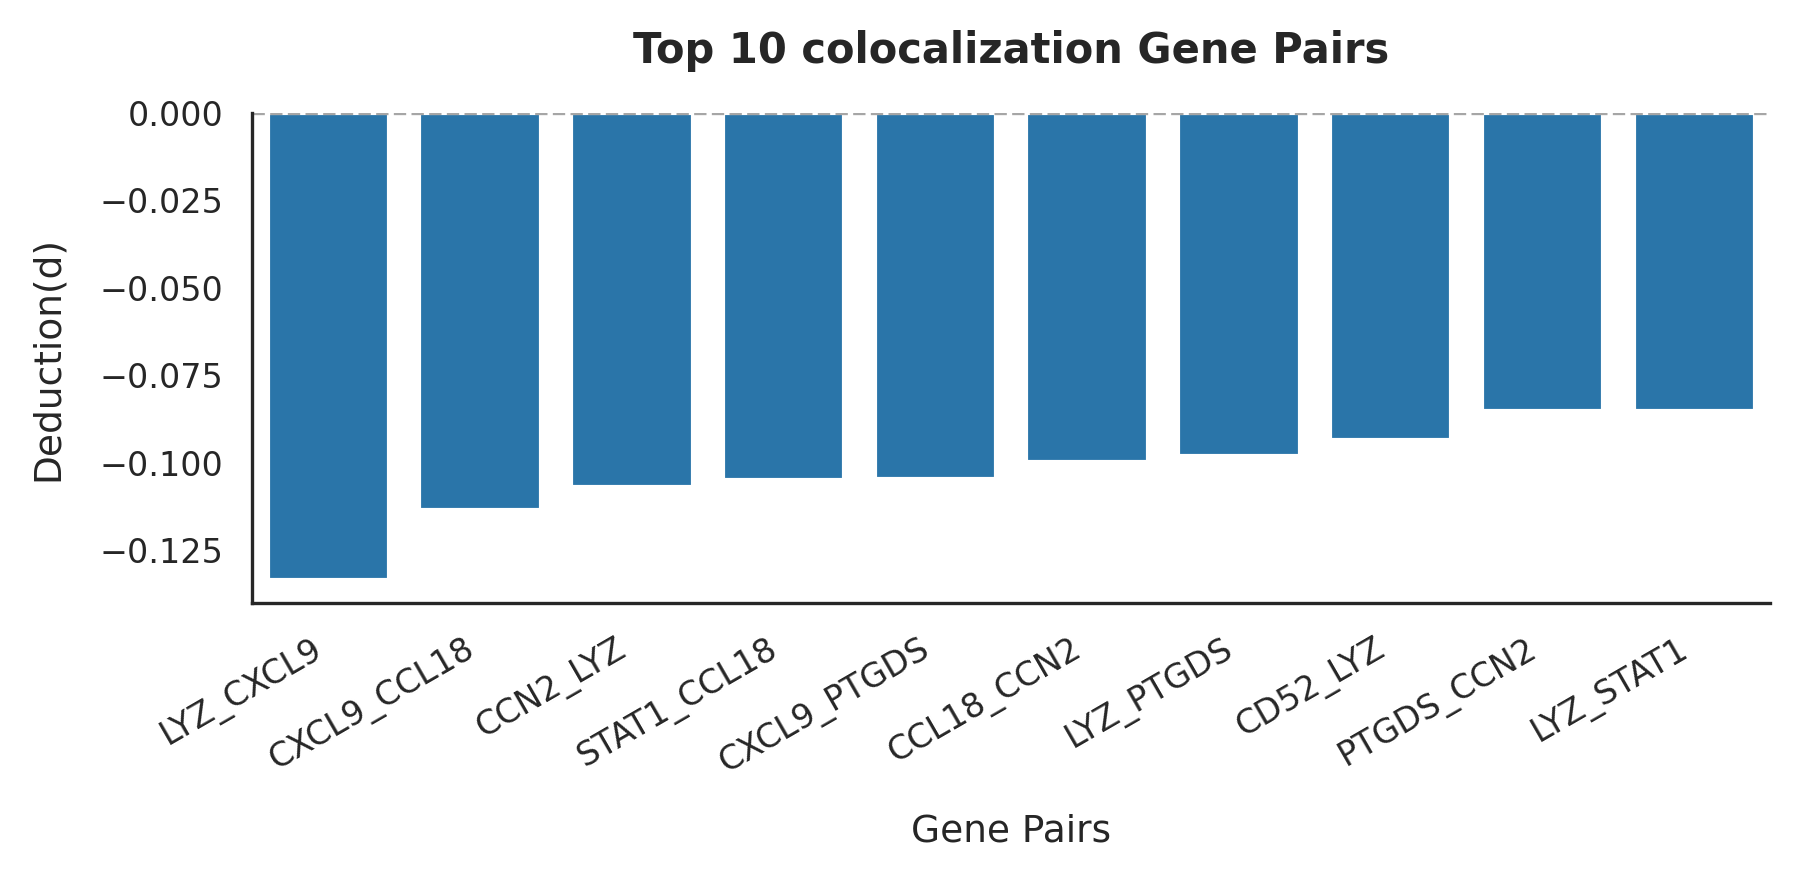

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set Nature-compliant style
sns.set_style("white")
plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'figure.figsize': (3.5, 2.8),
    'legend.fontsize': 8
})


# Create plot
plt.figure(figsize=(6, 3))
ax = sns.barplot(
    data=plot_df,
    x='gene_pairs',
    y='mean',
    errorbar='sd',      # Show standard deviation
    capsize=0.15,       # Error bar cap width
    errwidth=1.2,       # Error bar thickness
    saturation=0.85
)


# Refine aesthetics
plt.title('Top 10 colocalization Gene Pairs', fontweight='bold', pad=12)
plt.xlabel('Gene Pairs', labelpad=8)
plt.ylabel('Deduction(d)', labelpad=8)
plt.xticks(rotation=30, ha='right')  # Rotate labels for readability

# Custom horizontal line at y=0
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

sns.despine(top=True, right=True)
ax.grid(False)

# Adjust layout
plt.tight_layout()
plt.savefig('/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/figures/top_gene_pairs.png', format='png', dpi=300)
plt.show()

In [36]:
mac_t_pair_df[(mac_t_pair_df["P_value"]>0.05) & (mac_t_pair_df["10log(1-D)"]<-2)][:10]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol
8917,"(CD27, BANK1)",CD27,BANK1,-0.140222,34.666667,-1.082601,0.196072,3,"[[aaaalbni-1, aaaaajlb-1]]",[-0.3988914],False,-2.179631,-1
8977,"(CD247, BANK1)",CD247,BANK1,-0.172906,34.250000,-1.187501,0.222783,2,"[[aaaalbni-1, aaaalbnm-1]]",[-0.3185114],False,-2.738773,-1
9167,"(LCK, BANK1)",LCK,BANK1,-0.133009,44.333333,-1.868281,0.060340,6,"[[aaaalbni-1, aaaaajlb-1], [aaaalbni-1, aaaalb...","[-0.39058974, -0.3174042]",False,-2.059108,-1
9367,"(ITGB1, BANK1)",ITGB1,BANK1,-0.132150,39.250000,-1.853503,0.061497,6,"[[aaaalbni-1, aaaaajlb-1], [aaaalbni-1, aaaalb...","[-0.3969356, -0.3089436]",False,-2.044826,-1
12576,"(CXCL13, CCR7)",CXCL13,CCR7,-0.155356,31.125000,-1.548581,0.109620,4,"[[aaaagaop-1, aaaafpgm-1]]",[-0.42409196],True,-2.435856,-1
17301,"(CXCL13, MS4A1)",CXCL13,MS4A1,-0.147541,29.333333,-1.016980,0.208085,3,"[[aaaagaop-1, aaaafpgm-1]]",[-0.43769598],False,-2.302977,-1
18168,"(BANK1, CD52)",BANK1,CD52,-0.135044,38.700000,-1.563782,0.096456,5,"[[aaaalbni-1, aaaaajlb-1]]",[-0.39562142],False,-2.093009,-1
20220,"(BANK1, TNFRSF13C)",BANK1,TNFRSF13C,-0.207509,41.500000,-1.787422,0.162364,2,"[[aaaalbni-1, aaaaajlb-1]]",[-0.3236029],False,-3.355334,-1
22904,"(BANK1, UQCRHL)",BANK1,UQCRHL,-0.147785,40.500000,-0.996717,0.250523,2,"[[aaaalbni-1, aaaalbnm-1]]",[-0.2960558],False,-2.307098,-1
26363,"(CXCL9, GNG11)",CXCL9,GNG11,-0.161695,28.500000,-1.483141,0.188831,2,"[[aaaafpcd-1, aaaafomg-1]]",[-0.27071726],False,-2.544531,-1


In [45]:
mac_t_pair_df[(mac_t_pair_df["P_value"]<0.05) & (mac_t_pair_df["support_num"]<20)][:10]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol
60,"(LYZ, CD27)",LYZ,CD27,-0.015364,20.921053,-1.958596,0.032920,19,"[[aaaalbni-1, aaaaajlb-1], [aaaafnbj-1, aaaafn...","[-0.104958534, -0.10233343, -0.040358663, -0.0...",False,-0.223381,-1
63,"(LYZ, PDGFRB)",LYZ,PDGFRB,-0.012673,26.444444,-2.214661,0.020366,18,"[[aaaafkop-1, aaaafnmc-1], [aaaafpcd-1, aaaafo...","[-0.07143533, -0.055598855, -0.050866842, -0.0...",False,-0.183996,-1
297,"(HLA-DQA1, PDGFRB)",HLA-DQA1,PDGFRB,-0.004476,28.722222,-2.551209,0.010329,18,"[[aaaafkop-1, aaaafnmc-1], [aaaafnkp-1, aaaafn...","[-0.019551277, -0.01774937, -0.01656276, -0.01...",False,-0.064724,-1
372,"(STAT1, EPCAM)",STAT1,EPCAM,-0.002463,34.000000,-7.594744,0.041672,2,"[[aaaafnig-1, aaaafnii-1]]",[-0.0027873516],False,-0.035578,-1
373,"(STAT1, PDGFRB)",STAT1,PDGFRB,-0.014319,29.187500,-2.735050,0.007670,16,"[[aaaafmcf-1, aaaafmce-1], [aaaafobf-1, aaaafm...","[-0.06227839, -0.046920955, -0.046462893, -0.0...",False,-0.208069,-1
521,"(FN1, EPCAM)",FN1,EPCAM,-0.004752,33.500000,-15.847148,0.020060,2,"[[aaaafnil-1, aaaafnii-1]]",[-0.0050519705],False,-0.068722,-1
522,"(FN1, PDGFRB)",FN1,PDGFRB,-0.003417,36.571429,-3.327556,0.002725,14,"[[aaaafkop-1, aaaafnmc-1], [aaaafoka-1, aaaafo...","[-0.008711755, -0.008438945, -0.0058379173]",False,-0.049375,-1
666,"(HLA-DQB1, EPCAM)",HLA-DQB1,EPCAM,-0.000148,35.250000,-47.807692,0.006657,2,"[[aaaafnig-1, aaaafnii-1]]",[-0.00015127659],False,-0.002138,-1
737,"(FCER1G, EPCAM)",FCER1G,EPCAM,-0.000268,35.750000,-6.571010,0.048073,2,"[[aaaafnig-1, aaaafnii-1]]",[-0.00030821562],False,-0.003860,-1
876,"(PTPRC, EPCAM)",PTPRC,EPCAM,-0.000099,43.000000,-11.559441,0.027468,2,"[[aaaafnig-1, aaaafnii-1]]",[-0.00010704994],False,-0.001422,-1


For positive pairs

In [4]:
mac_t_ranked_df

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
8,"(LYZ, CXCL9)",LYZ,CXCL9,-0.033464,11.833333,-5.967193,1.017252e-08,135,"[[aaaafpcd-1, aaaafomg-1], [aaaaajmm-1, aaaaaj...","[-0.35607004, -0.29627734, -0.2472361, -0.2439...",False,-0.491047,-1,6.228618e-07
1209,"(CXCL9, CCL18)",CXCL9,CCL18,-0.026561,24.961538,-3.720337,1.729342e-04,91,"[[aaaafmcf-1, aaaafmce-1], [aaaaajnh-1, aaaaaj...","[-0.48423657, -0.29856122, -0.1716569, -0.1543...",False,-0.388376,-1,9.230162e-04
6415,"(CCN2, LYZ)",CCN2,LYZ,-0.025578,19.764286,-4.470316,1.493620e-05,70,"[[aaaafnln-1, aaaafnlf-1], [aaaafnmj-1, aaaafo...","[-0.17694986, -0.17425895, -0.16889274, -0.166...",False,-0.373814,-1,1.362182e-04
375,"(STAT1, CCL18)",STAT1,CCL18,-0.023734,17.793893,-4.360457,1.308143e-05,131,"[[aaaafmcf-1, aaaafmce-1], [aaaakncj-1, aaaakn...","[-0.46512812, -0.30961996, -0.2820341, -0.2019...",False,-0.346545,-1,1.242736e-04
8251,"(CD52, LYZ)",CD52,LYZ,-0.023077,20.147887,-4.545670,1.116309e-05,71,"[[aaaalbni-1, aaaalbnm-1], [aaaalbni-1, aaaaaj...","[-0.19736418, -0.15145674, -0.14975876, -0.127...",False,-0.336831,-1,1.106602e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5186,"(CD3E, GPR183)",CD3E,GPR183,-0.000994,27.588710,-1.808594,3.772163e-02,62,"[[aaaalbni-1, aaaaajlb-1], [aaaakncj-1, aaaakn...","[-0.018450141, -0.013640463, -0.00979054, -0.0...",False,-0.014351,-1,4.076081e-02
5846,"(HLA-DRA, ITGAM)",HLA-DRA,ITGAM,-0.000983,25.323529,-2.227515,1.522157e-02,51,"[[aaaaajnh-1, aaaaajnl-1], [aaaafnmj-1, aaaafo...","[-0.011962771, -0.0066690445, -0.0062894225, -...",False,-0.014188,-1,2.120025e-02
575,"(CD44, NFKB1)",CD44,NFKB1,-0.000952,20.875000,-1.797737,3.792760e-02,84,"[[aaaafkkb-1, aaaafkjk-1], [aaaafoka-1, aaaafo...","[-0.020196497, -0.01626879, -0.013900101, -0.0...",False,-0.013734,-1,4.091874e-02
212,"(HLA-DRA, TGFB1)",HLA-DRA,TGFB1,-0.000653,22.463964,-1.690157,4.691499e-02,111,"[[aaaafnpa-1, aaaafnnj-1], [aaaaajnh-1, aaaaaj...","[-0.015609145, -0.014552772, -0.012992144, -0....",False,-0.009420,-1,4.747759e-02


In [70]:
mac_t_ranked_df[mac_t_ranked_df["ligand_receptor"] == True]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
1200,"(CXCL9, CXCR4)",CXCL9,CXCR4,-0.012631,25.288462,-2.527955,0.006760,78,"[[aaaalbni-1, aaaaajlb-1], [aaaaajnh-1, aaaaaj...","[-0.19415766, -0.18760544, -0.09639412, -0.088...",True,-0.183387,-1,0.011826
284,"(HLA-DQA1, CD4)",HLA-DQA1,CD4,-0.003434,21.008621,-2.101234,0.018902,116,"[[aaaafnkk-1, aaaafnlg-1], [aaaafnln-1, aaaafn...","[-0.17479193, -0.04473591, -0.044460952, -0.02...",True,-0.049630,-1,0.024768
552,"(CD44, PTPRC)",CD44,PTPRC,-0.002381,12.358333,-2.584454,0.005275,180,"[[aaaalbni-1, aaaaajlb-1], [aaaafolp-1, aaaafo...","[-0.08463997, -0.06834179, -0.061566323, -0.05...",True,-0.034393,-1,0.009831
207,"(HLA-DRA, CD4)",HLA-DRA,CD4,-0.001621,18.491736,-2.986444,0.001711,121,"[[aaaafnln-1, aaaafnlf-1], [aaaafnkk-1, aaaafn...","[-0.03407538, -0.027837396, -0.01961428, -0.01...",True,-0.023405,-1,0.004590


In [5]:
mac_t_ranked_df[mac_t_ranked_df["gene1"] == "LYZ"]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
8,"(LYZ, CXCL9)",LYZ,CXCL9,-0.033464,11.833333,-5.967193,1.017252e-08,135,"[[aaaafpcd-1, aaaafomg-1], [aaaaajmm-1, aaaaaj...","[-0.35607004, -0.29627734, -0.2472361, -0.2439...",False,-0.491047,-1,6.228618e-07
9,"(LYZ, STAT1)",LYZ,STAT1,-0.022743,6.629032,-7.866216,1.477042e-13,186,"[[aaaafnpa-1, aaaafnnj-1], [aaaalbni-1, aaaalb...","[-0.24512714, -0.17455763, -0.15565795, -0.147...",False,-0.331907,-1,1.010297e-10
45,"(LYZ, PTGDS)",LYZ,PTGDS,-0.022415,10.375758,-5.567546,5.177100e-08,165,"[[aaaaajmm-1, aaaaajmi-1], [aaaafolp-1, aaaafo...","[-0.29210448, -0.25338435, -0.25227898, -0.237...",False,-0.327064,-1,2.083021e-06
65,"(LYZ, CCL18)",LYZ,CCL18,-0.022157,14.018797,-6.272550,2.351817e-09,133,"[[aaaakncj-1, aaaakncp-1], [aaaafnln-1, aaaafn...","[-0.18919462, -0.18635315, -0.18535298, -0.181...",False,-0.323246,-1,1.608643e-07
67,"(LYZ, SLC1A3)",LYZ,SLC1A3,-0.019070,16.873684,-5.282442,4.105703e-07,95,"[[aaaaajml-1, aaaaajmi-1], [aaaalbni-1, aaaalb...","[-0.15346813, -0.15266573, -0.1255688, -0.1083...",False,-0.277779,-1,8.023717e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6647,"(LYZ, CD3G)",LYZ,CD3G,-0.007592,20.711538,-2.634734,5.561706e-03,52,"[[aaaafnbj-1, aaaafnck-1], [aaaalbni-1, aaaalb...","[-0.09839386, -0.09281355, -0.0432595, -0.0413...",False,-0.109942,-1,1.025393e-02
29,"(LYZ, TRAC)",LYZ,TRAC,-0.006661,11.660000,-3.718260,1.663216e-04,100,"[[aaaalbni-1, aaaaajlb-1], [aaaalbni-1, aaaalb...","[-0.1057646, -0.07001877, -0.063234925, -0.055...",False,-0.096425,-1,9.153112e-04
76,"(LYZ, CD28)",LYZ,CD28,-0.006361,17.814516,-2.606011,5.747768e-03,62,"[[aaaalbni-1, aaaalbnm-1], [aaaafnbj-1, aaaafn...","[-0.09065771, -0.09062725, -0.043970883, -0.04...",False,-0.092061,-1,1.048393e-02
6641,"(LYZ, DCN)",LYZ,DCN,-0.005854,19.772727,-1.838203,3.530118e-02,66,"[[aaaagaop-1, aaaafpgm-1], [aaaafnln-1, aaaafn...","[-0.11314434, -0.074938595, -0.06575054, -0.06...",False,-0.084703,-1,3.851038e-02


For SPP1+ Macrophage and T

In [5]:
all_infos = pickle.load(open("/home/sxr280/Spatialformer/downstream/cell_cell_communication/data/all_infos_alllung_crop_id_T-cells_SPP1+ Macrophages.pkl", "rb"))
#Optional 1: use the CellChat database
database_path1 = "/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/data/ligand_receptor_database.csv"
#Optional 2: use the Cellnest database
database_path2 = "/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/data/CellNEST_database.csv"
spp1_t_pair_df = stat_test(all_infos, vocab)
spp1_t_pair_df = ovlp_database(spp1_t_pair_df, database_path1, database_path2)
spp1_t_ranked_df = filter_df(spp1_t_pair_df)

 18%|█▊        | 4289/23770 [00:02<00:09, 1977.71it/s]/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:502: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: invalid value encountered in double_scalars
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
100%|██████████| 23770/23770 [00:10<00:00, 2175.55it/s]
/home/sxr280/Spatialformer_6_10/utils/utils.py:1624: SettingWithCopyWarning: 
A value is trying to be set on a copy

In [8]:
spp1_t_pair_df[spp1_t_pair_df["gene2"] == "SPP1"]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol
14,"(VIM, SPP1)",VIM,SPP1,-0.000017,9.730435,-0.006309,0.497488,115,"[[aaaafofk-1, aaaafofh-1], [aaaafofh-1, aaaafo...","[-0.11516869, -0.096883774, -0.07783091, -0.07...",False,-0.000250,-1
66,"(LYZ, SPP1)",LYZ,SPP1,-0.019624,10.000000,-4.933824,0.000001,114,"[[aaaafofh-1, aaaafofk-1], [aaaafofk-1, aaaafo...","[-0.23570198, -0.19732237, -0.16867536, -0.118...",False,-0.285929,-1
117,"(HLA-DRA, SPP1)",HLA-DRA,SPP1,0.000776,11.267544,0.206346,0.581554,114,"[[aaaafofh-1, aaaafofk-1], [aaaafofk-1, aaaafo...","[-0.18234628, -0.16833204, -0.10566002, -0.096...",False,0.011204,1
167,"(CD44, SPP1)",CD44,SPP1,0.001008,12.858407,0.322240,0.626064,113,"[[aaaaajmm-1, aaaaajmo-1], [aaaafofk-1, aaaafo...","[-0.12823743, -0.117660224, -0.10871339, -0.07...",True,0.014557,1
216,"(SOD2, SPP1)",SOD2,SPP1,-0.015015,14.579646,-2.990304,0.001714,113,"[[aaaafofh-1, aaaafofk-1], [aaaafofk-1, aaaafo...","[-0.30361336, -0.2655385, -0.19211602, -0.1649...",False,-0.218270,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21948,"(TP73, SPP1)",TP73,SPP1,0.006415,26.750000,0.723402,0.699345,2,"[[aaaafofe-1, aaaafnop-1]]",[-0.0024527907],False,0.092845,1
22849,"(PLPP5, SPP1)",PLPP5,SPP1,0.014370,26.666667,4.927129,0.980595,3,"[[aaaafpha-1, aaaafpao-1]]",[0.009518862],False,0.208819,1
22978,"(PDCD1, SPP1)",PDCD1,SPP1,-0.000616,19.000000,NaN,NaN,1,"[[aaaafndk-1, aaaafndm-1]]",[-0.00061637163],False,-0.008895,-1
23038,"(SAA2, SPP1)",SAA2,SPP1,0.000151,22.500000,NaN,NaN,1,"[[aaaafndk-1, aaaafndm-1]]",[0.00015079975],False,0.002176,1


In [6]:
spp1_t_ranked_df[spp1_t_ranked_df["gene2"] == "SPP1"]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
1651,"(CXCL9, SPP1)",CXCL9,SPP1,-0.022538,22.110526,-2.926618,0.002148,95,"[[aaaafnke-1, aaaafnjk-1], [aaaafoga-1, aaaafo...","[-0.35907173, -0.345309, -0.3389208, -0.219516...",False,-0.328871,-1,0.004770
66,"(LYZ, SPP1)",LYZ,SPP1,-0.019624,10.000000,-4.933824,0.000001,114,"[[aaaafofh-1, aaaafofk-1], [aaaafofk-1, aaaafo...","[-0.23570198, -0.19732237, -0.16867536, -0.118...",False,-0.285929,-1,0.000030
216,"(SOD2, SPP1)",SOD2,SPP1,-0.015015,14.579646,-2.990304,0.001714,113,"[[aaaafofh-1, aaaafofk-1], [aaaafofk-1, aaaafo...","[-0.30361336, -0.2655385, -0.19211602, -0.1649...",False,-0.218270,-1,0.004044
358,"(STAT1, SPP1)",STAT1,SPP1,-0.009381,15.224299,-1.726476,0.043588,107,"[[aaaafnke-1, aaaafnjk-1], [aaaafnjk-1, aaaafn...","[-0.3632986, -0.28950608, -0.11933154, -0.0962...",False,-0.135983,-1,0.045029
3215,"(XBP1, SPP1)",XBP1,SPP1,-0.007630,31.992857,-1.743261,0.042871,70,"[[aaaafofk-1, aaaafofh-1], [aaaaajmm-1, aaaaaj...","[-0.14869267, -0.13503581, -0.13456666, -0.114...",False,-0.110506,-1,0.044485
6433,"(UBE2J1, SPP1)",UBE2J1,SPP1,-0.006489,29.368852,-1.820312,0.036850,61,"[[aaaafofk-1, aaaafofh-1], [aaaaajmm-1, aaaaaj...","[-0.11217493, -0.100712836, -0.09889567, -0.07...",False,-0.093928,-1,0.039734


In [7]:
spp1_t_ranked_df[spp1_t_ranked_df["gene1"] == "SPP1"]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
3694,"(SPP1, CCL18)",SPP1,CCL18,-0.012844,27.388889,-2.036286,0.022726,72,"[[aaaafofh-1, aaaafofk-1], [aaaafofk-1, aaaafo...","[-0.29822707, -0.27693516, -0.13536811, -0.103...",False,-0.186503,-1,0.027584


In [74]:
spp1_t_ranked_df[spp1_t_ranked_df["ligand_receptor"] == True]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
4071,"(CXCR4, CXCL9)",CXCR4,CXCL9,-0.016359,30.686567,-2.602641,0.005706,67,"[[aaaafkge-1, aaaafkhf-1], [aaaafkbl-1, aaaafk...","[-0.20648336, -0.16100568, -0.151164, -0.10245...",True,-0.237957,-1,0.009697
1026,"(FN1, CD44)",FN1,CD44,-0.011586,10.400685,-4.707284,0.000003,146,"[[aaaafkge-1, aaaafkhf-1], [aaaafnjk-1, aaaafn...","[-0.20305702, -0.16426486, -0.15006232, -0.121...",True,-0.168121,-1,0.000046
3966,"(ITGB1, FN1)",ITGB1,FN1,-0.009784,23.775000,-2.950488,0.002087,80,"[[aaaafnjk-1, aaaafnla-1], [aaaaajna-1, aaaaaj...","[-0.20926404, -0.11251181, -0.08798343, -0.050...",True,-0.141844,-1,0.004689
3778,"(FN1, ITGAV)",FN1,ITGAV,-0.006365,30.716981,-4.143902,0.000063,53,"[[aaaafnjp-1, aaaafnik-1], [aaaafkhf-1, aaaafk...","[-0.046907008, -0.033100843, -0.028284073, -0....",True,-0.092114,-1,0.000389
3683,"(HLA-DQA1, CD4)",HLA-DQA1,CD4,-0.003713,20.686916,-3.233302,0.000816,107,"[[aaaafnjk-1, aaaafnla-1], [aaaafofh-1, aaaafo...","[-0.07988709, -0.05415231, -0.042441428, -0.03...",True,-0.053667,-1,0.002374
3655,"(HLA-DRA, CD4)",HLA-DRA,CD4,-0.002622,18.400000,-2.509296,0.006784,110,"[[aaaafkge-1, aaaafkhf-1], [aaaaajmm-1, aaaaaj...","[-0.07673073, -0.04101628, -0.032001555, -0.02...",True,-0.037878,-1,0.011113
3968,"(ITGB1, ITGAX)",ITGB1,ITGAX,-0.002232,33.362069,-1.684181,0.048808,58,"[[aaaafkge-1, aaaafkhf-1], [aaaaajmf-1, aaaaaj...","[-0.0728901, -0.012869045, -0.007940829, -0.00...",True,-0.032237,-1,0.049017
506,"(PTPRC, CD44)",PTPRC,CD44,-0.002056,11.011299,-2.330448,0.010458,177,"[[aaaafkbl-1, aaaafkhf-1], [aaaafkge-1, aaaafk...","[-0.07670951, -0.06879109, -0.04572797, -0.033...",True,-0.029685,-1,0.015432
504,"(PTPRC, HLA-DRA)",PTPRC,HLA-DRA,-0.001775,9.660112,-1.839660,0.033747,178,"[[aaaafkge-1, aaaafkhf-1], [aaaaajmm-1, aaaaaj...","[-0.07734978, -0.056779265, -0.04174441, -0.04...",True,-0.025637,-1,0.037244


In [75]:
spp1_t_ranked_df

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
74,"(LYZ, CXCL9)",LYZ,CXCL9,-0.047327,13.914110,-6.360051,9.864647e-10,163,"[[aaaafofh-1, aaaafoga-1], [aaaafkbl-1, aaaafk...","[-0.46524993, -0.4335984, -0.41863698, -0.3427...",False,-0.699465,-1,3.081058e-07
1678,"(CXCL9, IL32)",CXCL9,IL32,-0.043398,39.333333,-3.987464,9.327933e-05,60,"[[aaaafofh-1, aaaafoga-1], [aaaafoga-1, aaaafo...","[-0.43387258, -0.4201885, -0.17806023, -0.1654...",False,-0.640095,-1,5.024945e-04
1652,"(CXCL9, GPR183)",CXCL9,GPR183,-0.040331,30.661290,-3.188182,1.129880e-03,62,"[[aaaafofh-1, aaaafoga-1], [aaaafoga-1, aaaafo...","[-0.5303677, -0.49471623, -0.1928044, -0.17998...",False,-0.593909,-1,3.041292e-03
1681,"(CXCL9, EHMT1)",CXCL9,EHMT1,-0.038790,33.054688,-3.764424,1.845377e-04,64,"[[aaaafofh-1, aaaafoga-1], [aaaafoga-1, aaaafo...","[-0.44414666, -0.42771512, -0.16951069, -0.140...",False,-0.570759,-1,8.117086e-04
224,"(SOD2, CXCL9)",SOD2,CXCL9,-0.037177,17.960123,-6.041465,5.062932e-09,163,"[[aaaafofh-1, aaaafoga-1], [aaaafoga-1, aaaafo...","[-0.46411625, -0.44469973, -0.3388905, -0.2883...",False,-0.546581,-1,7.906613e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,"(SSR3, PTPRC)",SSR3,PTPRC,-0.000808,31.357143,-1.758958,4.130480e-02,77,"[[aaaaajmf-1, aaaaajmo-1], [aaaafndo-1, aaaafk...","[-0.028803766, -0.009062171, -0.008208215, -0....",False,-0.011655,-1,4.319486e-02
7720,"(NUTF2, ATF4)",NUTF2,ATF4,-0.000763,38.604839,-1.986793,2.572095e-02,62,"[[aaaafkbl-1, aaaafkhf-1], [aaaafkhf-1, aaaafk...","[-0.017813504, -0.011203229, -0.006017506, -0....",False,-0.011009,-1,3.001311e-02
5344,"(TGFB1, SPCS3)",TGFB1,SPCS3,-0.000762,39.785714,-1.993112,2.443420e-02,105,"[[aaaafkge-1, aaaafkhf-1], [aaaafkbl-1, aaaafk...","[-0.021747053, -0.015627563, -0.015210211, -0....",False,-0.011002,-1,2.892690e-02
4144,"(XBP1, AIF1)",XBP1,AIF1,-0.000758,39.500000,-1.784118,3.917198e-02,78,"[[aaaafkge-1, aaaafkhf-1], [aaaaajmm-1, aaaaaj...","[-0.022628069, -0.011756599, -0.009382665, -0....",False,-0.010934,-1,4.159975e-02


# Visualization

In [1]:
import os
import sys

# Set R_HOME to your path from Step 1
r_home = "/home/sxr280/miniconda3/envs/spatialformer/lib/R"  
if os.path.exists(r_home):
    os.environ['R_HOME'] = r_home
else:
    raise FileNotFoundError(f"R_HOME path not found: {r_home}")

In [2]:
%%capture
%load_ext rpy2.ipython

In [7]:
pair_df = mac_t_pair_df

In [8]:
%R -i pair_df

/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "gene_pair". Fall back to string conversion. The error is: <class 'tuple'>
  warnings.warn('Error while trying to convert '
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "top20_cellpairs". Fall back to string conversion. The error is: <class 'numpy.ndarray'>
  warnings.warn('Error while trying to convert '
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "top20_diff". Fall back to string conversion. The error is: <class 'numpy.ndarray'>
  warnings.warn('Error while trying to convert '


[1] 3.007178e-08
               gene_pair gene1  gene2  Deduction rank_mean stat P_value
25527 ('MEG3', 'CXCL13')  MEG3 CXCL13 -0.4253024      34.0  NaN     NaN
20218  ('BANK1', 'MEG3') BANK1   MEG3 -0.4195694      41.5  NaN     NaN
      support_num               top20_cellpairs    top20_diff ligand_receptor
25527           1 [['aaaagaop-1' 'aaaafpgm-1']] [-0.42530245]           FALSE
20218           1 [['aaaalbni-1' 'aaaaajlb-1']] [-0.41956943]           FALSE
      10log(1-D) symbol Transformed_Deduction Color
25527  -7.991251     -1             0.5539114  grey
20218  -7.848046     -1             0.5439851  grey
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


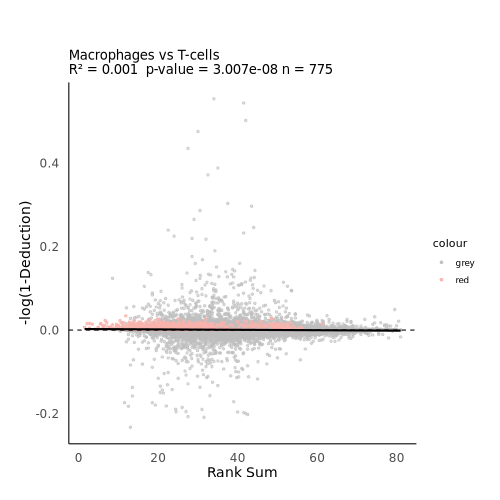

In [52]:
%%R -w 500 -h 500
library(ggplot2)
# library(ggrepel)  # For better text label placement
library(dplyr)    # For data manipulation
library(MASS)     # For kde2d
library(ggpointdensity)
library(viridis)
pair_df$Transformed_Deduction <- -log(1-(-pair_df$Deduction)) #only select minus pairs
# horizon_line <- 0
# Perform linear regression
model <- lm(Transformed_Deduction ~ rank_mean, data = pair_df)
summary_model <- summary(model)
r_squared <- summary_model$r.squared
p_value <- summary_model$coefficients[2, 4]  # p-value for the rank_sum coefficient\
print(p_value)
# # Identify the top 2 pairs with max log(Deduction)
top_pairs <- pair_df[order(pair_df$Transformed_Deduction, decreasing = TRUE), ][1:2, ]
print(top_pairs)
# Add a column for color based on p-value
# Add a column for color based on p-value and your conditions
pair_df$Color <- NA
pair_df$Color[pair_df$P_value < 0.05 & pair_df$Deduction < 0 & pair_df$stat < 0 & pair_df$support_num > 50] <- "red"
# Map colors: significant points are in red with a gradient based on significance
pair_df$Color <- ifelse(is.na(pair_df$Color), "grey", pair_df$Color)  # Non-significant = grey
# head(df)
# Set non-significant points to grey
pair_df$Color[is.na(pair_df$Color)] <- "grey"
num_significant <- sum(pair_df$Color == "red")
# df$Significance_Score <- 1 / df$P_value
# Create the scatter plot
p <- ggplot(pair_df, aes(x = rank_mean, y = Transformed_Deduction)) +
    geom_point(data = pair_df[pair_df$Color == "grey", ], aes(color = "grey"), size = 1, alpha = 0.6) +  # Plot grey dots first
    geom_point(data = pair_df[pair_df$Color == "red", ], aes(color = "red"), size = 1, alpha = 0.8) +    # Overlay red dots
    geom_smooth(method = "lm", color = "black", se = FALSE) +                                          # Add linear regression line
    geom_hline(yintercept = 0, linetype = "dashed", color = "black") +                                # Horizontal line at y=0
    labs(x = "Rank Sum", 
         y = "-log(1-Deduction)", 
         title = paste("Macrophages vs T-cells", "\nR² =", round(r_squared, 3), 
                       " p-value =", formatC(p_value, format = "e", digits = 3), 
                       "n =", num_significant)) +
    scale_color_manual(values = c("grey" = "grey", "red" = "#F9B3AD")) +  # Define explicit colors
    theme_minimal() +
    theme(
        plot.margin = margin(t = 50, r = 20, b = 20, l = 20),  # Increase margin
        axis.title.x = element_text(size = 14),    # Increase x-axis label size
        axis.title.y = element_text(size = 14),    # Increase y-axis label size
        axis.text.x = element_text(size = 12),      # Increase x-axis tick label size
        axis.text.y = element_text(size = 12),
        axis.line = element_line(colour = "black"),
        panel.border = element_blank(),  # Remove panel border
        panel.grid = element_blank(),     # Remove grid lines
        axis.ticks.length = unit(0.25, "cm")   # Adjust tick length if needed
    )
ggsave("/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/figures/macrophages_vs_tcells_plot.png", plot = p, width = 8, height = 8, dpi = 300, bg = "white") 
print(p)

In [55]:
mac_t_filtered_df = mac_t_pair_df[(mac_t_pair_df["support_num"] > 10)]
mac_t_filtered_df["-logp"] = -np.log(mac_t_filtered_df["P_value"])

/tmp/ipykernel_3549873/414382862.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mac_t_filtered_df["-logp"] = -np.log(mac_t_filtered_df["P_value"])


In [56]:
mac_t_filtered_df.sort_values(by="-logp", ascending=False)

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,-logp
9,"(LYZ, STAT1)",LYZ,STAT1,-0.022743,6.629032,-7.866216,1.477042e-13,186,"[[aaaafnpa-1, aaaafnnj-1], [aaaalbni-1, aaaalb...","[-0.24512714, -0.17455763, -0.15565795, -0.147...",False,-0.331907,-1,29.543565
5,"(LYZ, HLA-DQA1)",LYZ,HLA-DQA1,-0.014982,5.581081,-6.938782,3.266538e-11,185,"[[aaaalbni-1, aaaalbnm-1], [aaaaajml-1, aaaaaj...","[-0.16100234, -0.15907419, -0.13609493, -0.127...",False,-0.217783,-1,24.144705
0,"(LYZ, VIM)",LYZ,VIM,-0.015330,2.076531,-6.905727,3.435885e-11,196,"[[aaaalbni-1, aaaalbnm-1], [aaaalbni-1, aaaaaj...","[-0.18519723, -0.16012031, -0.1533047, -0.1312...",False,-0.222883,-1,24.094162
2,"(LYZ, HLA-DRA)",LYZ,HLA-DRA,-0.014143,3.399485,-6.712676,1.037487e-10,194,"[[aaaaajml-1, aaaaajmi-1], [aaaafnbj-1, aaaafn...","[-0.15802974, -0.1277113, -0.12729374, -0.1253...",False,-0.205495,-1,22.989050
4,"(LYZ, CD44)",LYZ,CD44,-0.015455,5.462162,-6.453831,4.697739e-10,185,"[[aaaalbni-1, aaaalbnm-1], [aaaalbni-1, aaaaaj...","[-0.19636646, -0.15299043, -0.14262962, -0.133...",False,-0.224714,-1,21.478770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
731,"(FCER1G, CXCR4)",FCER1G,CXCR4,0.004221,22.516667,3.453809,9.995758e-01,90,"[[aaaaajnh-1, aaaaajnl-1], [aaaafnkc-1, aaaafk...","[-0.006056428, -0.0041621923, -0.003333509, -0...",False,0.061021,1,0.000424
688,"(FCER1G, RHOA)",FCER1G,RHOA,0.002165,19.787313,3.430910,9.995991e-01,134,"[[aaaafnkk-1, aaaafnlg-1], [aaaafnkc-1, aaaafk...","[-0.017834187, -0.0076228976, -0.003480494, -0...",False,0.031269,1,0.000401
695,"(FCER1G, PTPRC)",FCER1G,PTPRC,0.001871,17.458065,3.526737,9.997227e-01,155,"[[aaaafnkc-1, aaaafkln-1], [aaaafnhf-1, aaaafn...","[-0.0068373084, -0.0064757466, -0.0047450066, ...",False,0.027015,1,0.000277
726,"(FCER1G, ZEB1)",FCER1G,ZEB1,0.003236,31.339286,3.971010,9.997611e-01,28,"[[aaaafncb-1, aaaafncc-1], [aaaafncc-1, aaaafn...","[-0.0017872453, -0.00069230795, -0.0005427003,...",False,0.046761,1,0.000239


In [57]:
filtered_df = mac_t_filtered_df
filter_lt = mac_t_ranked_df

In [58]:
%R -i filtered_df

/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "gene_pair". Fall back to string conversion. The error is: <class 'tuple'>
  warnings.warn('Error while trying to convert '
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "top20_cellpairs". Fall back to string conversion. The error is: <class 'numpy.ndarray'>
  warnings.warn('Error while trying to convert '
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "top20_diff". Fall back to string conversion. The error is: <class 'numpy.ndarray'>
  warnings.warn('Error while trying to convert '


In [59]:
%R -i filter_lt

/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "gene_pair". Fall back to string conversion. The error is: <class 'tuple'>
  warnings.warn('Error while trying to convert '
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "top20_cellpairs". Fall back to string conversion. The error is: <class 'numpy.ndarray'>
  warnings.warn('Error while trying to convert '
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "top20_diff". Fall back to string conversion. The error is: <class 'numpy.ndarray'>
  warnings.warn('Error while trying to convert '


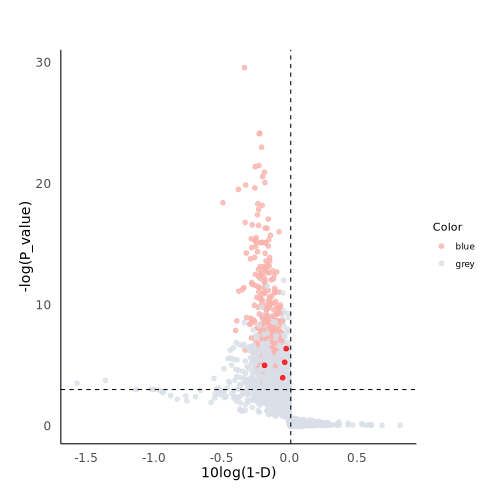

In [61]:
%%R -w 500 -h 500
# Load necessary libraries
library(ggplot2)
library(dplyr)


# Calculate the transformed deduction

# Create a binary color column based on significance and conditions 
filtered_df$Color <- ifelse(filtered_df$P_value < 0.05 & filtered_df$`10log(1-D)` < (10*log(1-0.005)) & filtered_df$support_num > 50, "blue", "grey")
# Mark the 10th row with a unique identifier
filtered_df$Highlight <- FALSE

if (nrow(filtered_df) >= 10) {
  gene_pair1_to_highlight <- "('CXCL9', 'CXCR4')"
  gene_pair2_to_highlight <- "('HLA-DQA1', 'CD4')"
  gene_pair3_to_highlight <- "('CD44', 'PTPRC')"
  gene_pair4_to_highlight <- "('HLA-DRA', 'CD4')"
  # Create a logical vector for highlighting
  filtered_df$Highlight <- (filtered_df$gene_pair %in% c(gene_pair1_to_highlight, gene_pair2_to_highlight, gene_pair3_to_highlight, gene_pair4_to_highlight))
}

# Create the volcano plot
p <- ggplot(filtered_df, aes(x = `10log(1-D)`, y = -log(P_value), color = Color)) +
    geom_point(data = subset(filtered_df, Highlight == FALSE), aes(color = Color), size = 2, alpha = 0.8) +  # Plot grey points first
    geom_point(data = subset(filtered_df, Highlight == TRUE), color = "red", size = 2, alpha = 0.8) +        # Plot red points after
    scale_color_manual(values = c("grey" = "#D9DEE7", "blue" = "#F9B3AD")) +                                # Define explicit colors                                    # Horizontal line at y=0
    geom_hline(yintercept = -log(0.05), linetype = "dashed", color = "black") +                             # Horizontal line for p-value threshold
    geom_vline(xintercept = -10 * log(1 - 0.001), linetype = "dashed", color = "black") +                   # Vertical line at threshold
    theme_minimal() +
    theme(
        plot.margin = margin(t = 50, r = 20, b = 20, l = 20),  # Increase margin
        axis.title.x = element_text(size = 14),               # Increase x-axis label size
        axis.title.y = element_text(size = 14),               # Increase y-axis label size
        axis.text.x = element_text(size = 12),                # Increase x-axis tick label size
        axis.text.y = element_text(size = 12),
        axis.line = element_line(colour = "black"),           # Black axis lines
        panel.border = element_blank(),                      # Remove panel border
        panel.grid = element_blank(),                        # Remove grid lines
        axis.ticks.length = unit(0.25, "cm")                 # Adjust tick length
    )

ggsave("/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/figures/macrophages_vs_tcells_volcano_plot.png", plot = p, width = 8, height = 8, dpi = 300, bg = "white") 

# Show the plot
print(p)

For negative sample visualization

In [29]:
filtered_df = mac_t_pair_df

In [33]:
%R -i filtered_df

/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "gene_pair". Fall back to string conversion. The error is: <class 'tuple'>
  warnings.warn('Error while trying to convert '
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "top20_cellpairs". Fall back to string conversion. The error is: <class 'numpy.ndarray'>
  warnings.warn('Error while trying to convert '
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "top20_diff". Fall back to string conversion. The error is: <class 'numpy.ndarray'>
  warnings.warn('Error while trying to convert '


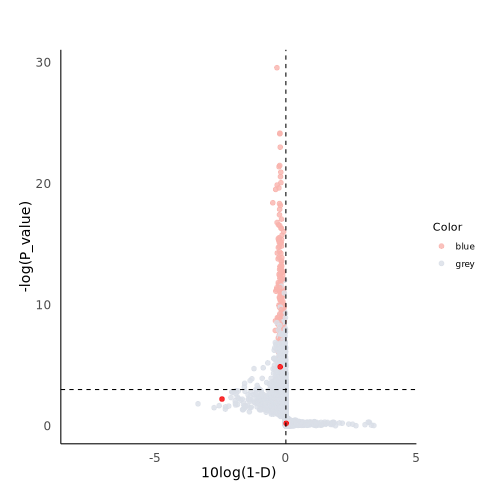

In [47]:
%%R -w 500 -h 500
# Load necessary libraries
library(ggplot2)
library(dplyr)


# Calculate the transformed deduction

# Create a binary color column based on significance and conditions 
filtered_df$Color <- ifelse(filtered_df$P_value < 0.05 & filtered_df$`10log(1-D)` < (10*log(1-0.005)) & filtered_df$support_num > 50, "blue", "grey")
# Mark the 10th row with a unique identifier
filtered_df$Highlight <- FALSE

if (nrow(filtered_df) >= 10) {
  gene_pair1_to_highlight <- "('CD274', 'CD4')"
  gene_pair2_to_highlight <- "('CXCL13', 'CCR7')"
  gene_pair3_to_highlight <- "('STAT1', 'PDGFRB')"
  # Create a logical vector for highlighting
  filtered_df$Highlight <- (filtered_df$gene_pair %in% c(gene_pair1_to_highlight, gene_pair2_to_highlight, gene_pair3_to_highlight))
}

# Create the volcano plot
p <- ggplot(filtered_df, aes(x = `10log(1-D)`, y = -log(P_value), color = Color)) +
    geom_point(aes(color = Color), size = 2, alpha = 0.8) +  # Points with specified color
    geom_point(data = subset(filtered_df, Highlight == TRUE), color = "red", size = 2, alpha = 0.8) +  # Highlight the 10th point
    scale_color_manual(values = c("grey" = "#D9DEE7", "blue" = "#F9B3AD")) +  # Define explicit colors    geom_hline(yintercept = 0, linetype = "dashed", color = "black") +  # Horizontal line at y=0
    geom_hline(yintercept = -log(0.05), linetype = "dashed", color = "black") +
    geom_vline(xintercept = -10*log(1-0.001), linetype = "dashed", color = "black") +
#     geom_vline(xintercept = 10*log(1), linetype = "dashed", color = "black")+
    theme_minimal() +
    theme(
        plot.margin = margin(t = 50, r = 20, b = 20, l = 20),  # Increase margin
        axis.title.x = element_text(size = 14),    # Increase x-axis label size
        axis.title.y = element_text(size = 14),    # Increase y-axis label size
        axis.text.x = element_text(size = 12),      # Increase x-axis tick label size
        axis.text.y = element_text(size = 12),
        axis.line = element_line(colour = "black"),  # Black axis lines
        panel.border = element_blank(),               # Remove panel border
        panel.grid = element_blank(),                 # Remove grid lines
        axis.ticks.length = unit(0.25, "cm")        # Adjust tick length
    )
ggsave("/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/figures/macrophages_vs_tcells_volcano_plot_negative.png", plot = p, width = 8, height = 8, dpi = 300, bg = "white") 

# Show the plot
print(p)

The gene pairs can correctly identify the molecular process based on "Collagen-Containing Extracellular Matrix" by gene ontology analysis. And in the biological process, it indicates a strong cellular imigration features.

Show the reactome pathway, the most significant is immune system, which well to the granuloma features in PF paradim

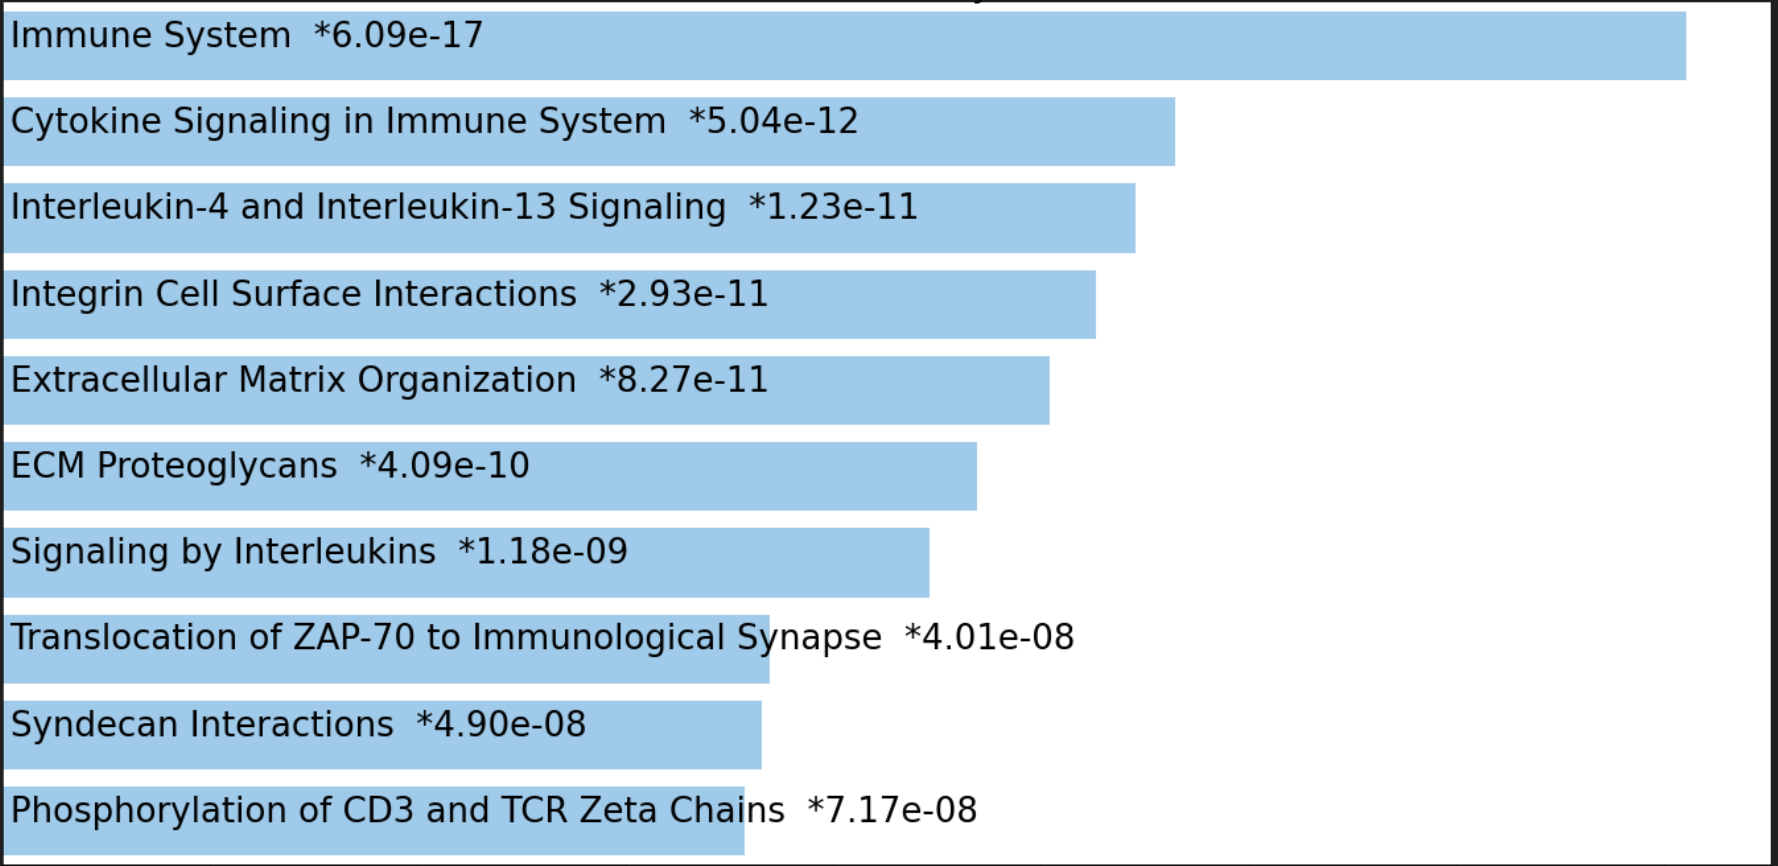

In [27]:
from IPython.display import Image, display
# Specify the path to your image
image_path = '/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/figures/reactome_T_macrophage_perturbation_genes.jpg'
# Display the image using IPython
display(Image(filename=image_path))

Show the cellular component results
where collagen-containing extracellular matrix is important in fibrosis development.

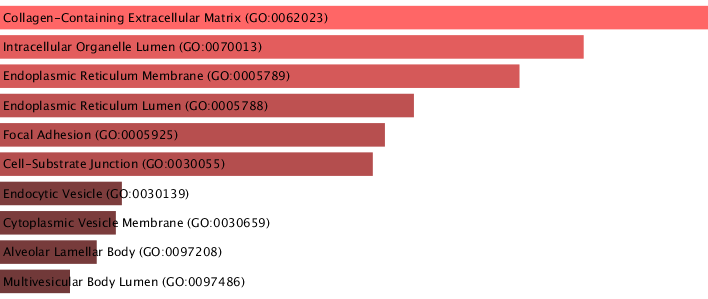

In [28]:
from IPython.display import Image, display
# Specify the path to your image
image_path = '/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/figures/GO_Cellular_Component_2023_bar_graph_T_Macrophages.png'
# Display the image using IPython
display(Image(filename=image_path))